Libraries loaded successfully
Total rows : 15,422
Total cols : 1,046
Total sample : 15,422
Youth sample : 2,577  (age 19-39)
Missing codes cleaned
=== DSR distribution (after cap) ===
count    1916.000000
mean        0.302388
std         0.800798
min         0.000000
25%         0.000000
50%         0.030077
75%         0.209511
max         5.000000
Name: dsr, dtype: float64

=== Crisis rate by DSR threshold ===
  DSR >= 0.2 :  499 crisis  (26.0%)
  DSR >= 0.3 :  361 crisis  (18.8%)
  DSR >= 0.4 :  299 crisis  (15.6%)
  DSR >= 0.5 :  251 crisis  (13.1%)
  DSR >= 0.6 :  221 crisis  (11.5%)
  DSR >= 0.7 :  191 crisis  (10.0%)

=== Final sample (income earners only) ===
Income earners : 1,916

=== DSR (regression target) ===
count    1916.000000
mean        0.302388
std         0.800798
min         0.000000
25%         0.000000
50%         0.030077
75%         0.209511
max         5.000000
Name: dsr, dtype: float64

=== Crisis flag (reference only) ===
Crisis  (DSR>=0.4) : 299  (15.6%)
No

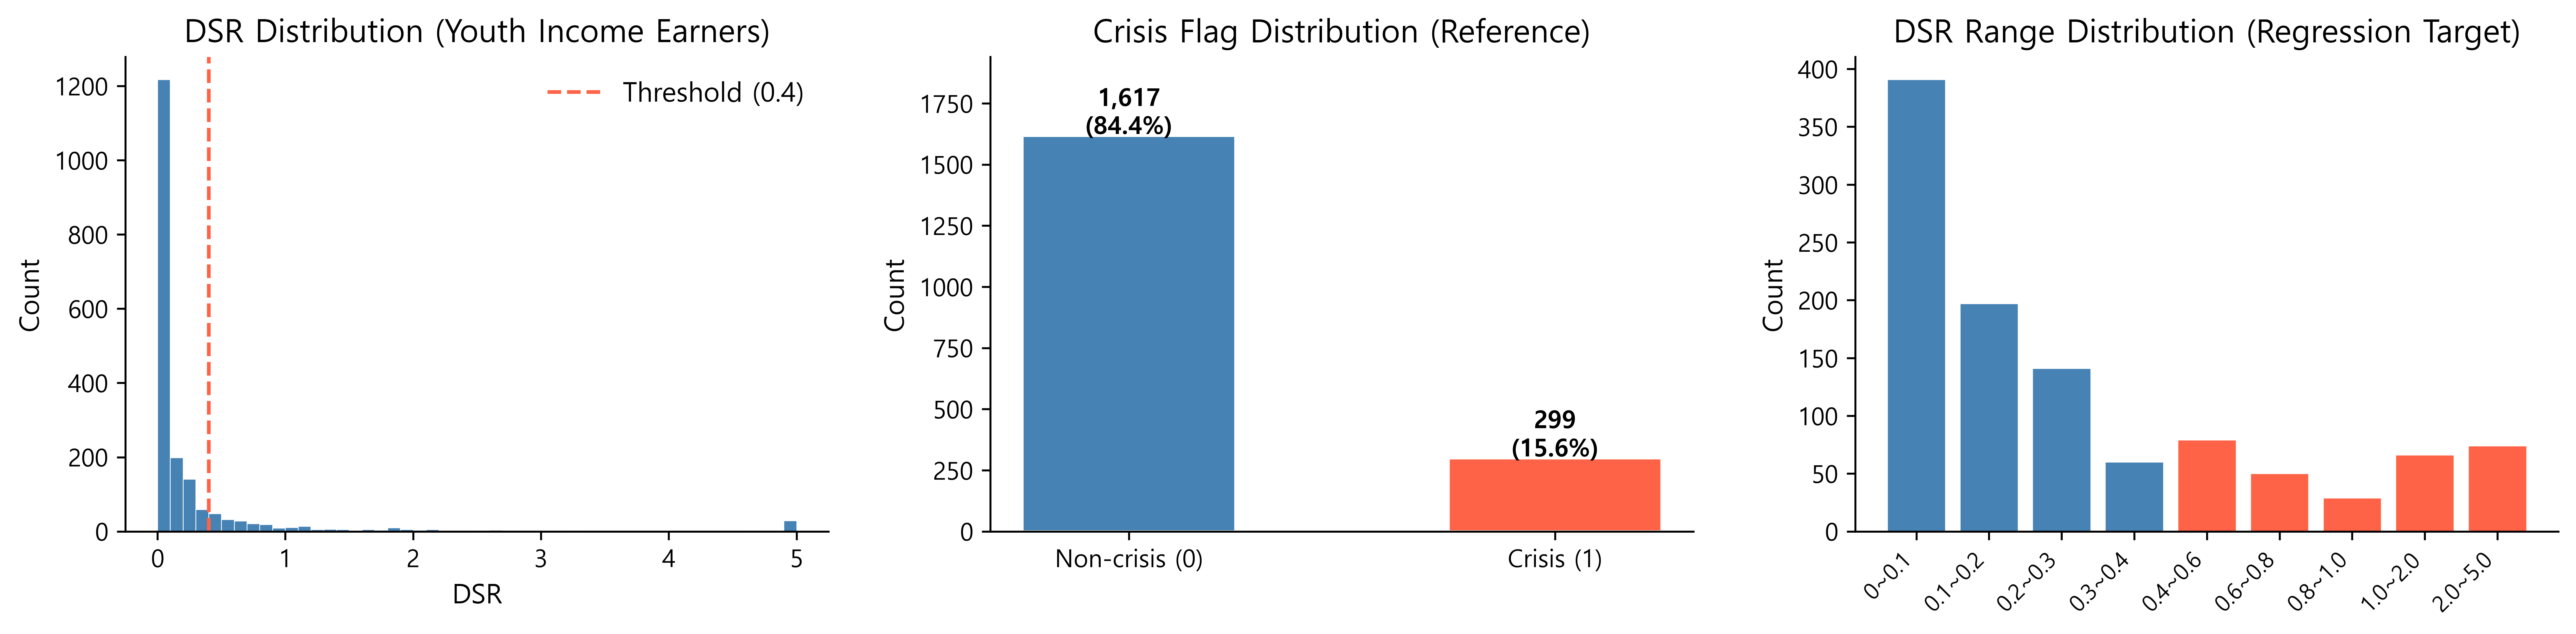

Saved -> outputs/dsr_distribution_regression.png
Final dataset shape : (1916, 38)

=== 회귀 타겟(dsr) 최종 기술통계 ===
count    1916.000000
mean        0.302388
std         0.800798
min         0.000000
25%         0.000000
50%         0.030077
75%         0.209511
max         5.000000
Name: dsr, dtype: float64
Saved (regression) -> ../data/youth_debt_preprocessed_regression.csv
Saved (compatible)  -> ../data/youth_debt_preprocessed.csv

Shape  : (1916, 38)
Columns: ['h19_pid', 'p19_wgc', 'sex', 'h19_g4', 'education', 'marital_status', 'region', 'employment_status', 'employment_type', 'h19_pers_income1', 'h19_pers_income2', 'h19_pers_income3', 'h19_pers_income4', 'h19_pers_income5', 'h19_cin', 'h19_din', 'debt_financial', 'debt_private', 'debt_card', 'debt_lease', 'debt_credit', 'debt_other', 'h1909_aq7', 'h1909_aq8', 'h1906_aq2', 'housing_debt_balance', 'h1906_10', 'housing_tenure', 'age', 'total_income', 'total_debt', 'annual_interest', 'annual_repayment', 'annual_debt_service', 'dsr_raw', 'd

In [1]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 01_preprocessing_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Data loading, cleaning, DSR construction, and export
#             (regression version -- continuous DSR as target)
# Data      : KOWEPS 19th Wave (2024), n=1,916 youth aged 19-39
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load raw data
# ─────────────────────────────────────────────
DATA_PATH = "../data/koweps_hpc19_2024_beta2.dta"

df_raw = pd.read_stata(DATA_PATH, convert_categoricals=False)

print(f"Total rows : {df_raw.shape[0]:,}")
print(f"Total cols : {df_raw.shape[1]:,}")


# ─────────────────────────────────────────────
# Cell 3 | Select relevant variables
# ─────────────────────────────────────────────
cols_use = [
    'h19_pid', 'p19_wgc',
    'h19_g3', 'h19_g4', 'h19_g6', 'h19_g10', 'h19_reg5',
    'h19_eco4', 'h19_eco5_1',
    'h19_pers_income1', 'h19_pers_income2', 'h19_pers_income3',
    'h19_pers_income4', 'h19_pers_income5',
    'h19_cin', 'h19_din',
    'h1909_aq1', 'h1909_aq2', 'h1909_aq3',
    'h1909_aq4', 'h1909_aq5', 'h1909_aq6',
    'h1909_aq7', 'h1909_aq8',
    'h1906_aq2', 'h1906_aq3', 'h1906_10', 'h1906_3',
]

df = df_raw[cols_use].copy()


# ─────────────────────────────────────────────
# Cell 4 | Filter youth aged 19-39
# ─────────────────────────────────────────────
SURVEY_YEAR = 2024
df['age'] = SURVEY_YEAR - df['h19_g4']
df_youth = df[(df['age'] >= 19) & (df['age'] <= 39)].copy()

print(f"Total sample : {len(df):,}")
print(f"Youth sample : {len(df_youth):,}  (age 19-39)")


# ─────────────────────────────────────────────
# Cell 5 | Clean missing value codes
# ─────────────────────────────────────────────
DEBT_COLS = ['h1909_aq1','h1909_aq2','h1909_aq3',
             'h1909_aq4','h1909_aq5','h1909_aq6',
             'h1909_aq7','h1909_aq8']
for col in DEBT_COLS:
    df_youth[col] = df_youth[col].replace(9999999, np.nan)

for col in ['h1906_aq2', 'h1906_aq3']:
    df_youth[col] = df_youth[col].replace(999999, np.nan)

df_youth['h1906_10'] = df_youth['h1906_10'].replace(9, np.nan)

INCOME_COLS = ['h19_pers_income1','h19_pers_income2','h19_pers_income3',
               'h19_pers_income4','h19_pers_income5']
for col in INCOME_COLS:
    df_youth[col] = df_youth[col].apply(lambda x: x if x >= 0 else np.nan)

print("Missing codes cleaned")


# ─────────────────────────────────────────────
# Cell 6 | Construct key features
# ─────────────────────────────────────────────
df_youth['total_income'] = df_youth[INCOME_COLS].fillna(0).sum(axis=1)

df_youth['total_debt'] = df_youth[['h1909_aq1','h1909_aq2','h1909_aq3',
                                    'h1909_aq4','h1909_aq5','h1909_aq6']]\
                                   .fillna(0).sum(axis=1)

df_youth['annual_interest'] = df_youth[['h1909_aq7','h1909_aq8']].fillna(0).sum(axis=1)
df_youth['annual_repayment'] = df_youth['h1906_aq2'].fillna(0)
df_youth['annual_debt_service'] = df_youth['annual_interest'] + df_youth['annual_repayment']


# ─────────────────────────────────────────────
# Cell 7 | Compute DSR (with outlier cap)
# ─────────────────────────────────────────────
df_youth['dsr_raw'] = np.where(
    df_youth['total_income'] > 0,
    df_youth['annual_debt_service'] / df_youth['total_income'],
    np.nan
)

df_youth['dsr'] = df_youth['dsr_raw'].clip(upper=5.0)

print("=== DSR distribution (after cap) ===")
print(df_youth['dsr'].describe())

print("\n=== Crisis rate by DSR threshold ===")
for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    n = (df_youth['dsr'] >= thr).sum()
    rate = n / df_youth['dsr'].notna().sum()
    print(f"  DSR >= {thr:.1f} : {n:>4,} crisis  ({rate:.1%})")


# ─────────────────────────────────────────────
# Cell 8 | Define target variable
# [변경] 회귀용: DSR 연속값을 주 타겟으로 사용
#        분류용 debt_crisis는 기술통계 비교용으로만 유지
# ─────────────────────────────────────────────
df_income = df_youth[df_youth['total_income'] > 0].copy()

# 회귀 타겟: DSR 연속값 (주 타겟)
# df_income['dsr'] 를 모델링에 사용

# 분류 레이블은 참조/기술통계용으로만 보존
df_income['debt_crisis'] = (df_income['dsr'] >= 0.4).astype(int)

print(f"\n=== Final sample (income earners only) ===")
print(f"Income earners : {len(df_income):,}")
print(f"\n=== DSR (regression target) ===")
print(df_income['dsr'].describe())
print(f"\n=== Crisis flag (reference only) ===")
print(f"Crisis  (DSR>=0.4) : {df_income['debt_crisis'].sum():,}  ({df_income['debt_crisis'].mean():.1%})")
print(f"Non-crisis         : {(df_income['debt_crisis']==0).sum():,}  ({(df_income['debt_crisis']==0).mean():.1%})")


# ─────────────────────────────────────────────
# Cell 9 | Visualize DSR distribution
# [변경] 회귀 타겟 관점의 시각화 추가
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) DSR 전체 히스토그램
axes[0].hist(df_income['dsr'].dropna(), bins=50,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0.4, color='tomato', linestyle='--',
                linewidth=1.5, label='Threshold (0.4)')
axes[0].set_xlabel('DSR')
axes[0].set_ylabel('Count')
axes[0].set_title('DSR Distribution (Youth Income Earners)')
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (2) Crisis vs non-crisis bar (참조용)
counts = df_income['debt_crisis'].value_counts().sort_index()
bars = axes[1].bar(['Non-crisis (0)', 'Crisis (1)'],
                   counts.values,
                   color=['steelblue', 'tomato'],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 8,
                 f'{val:,}\n({val/len(df_income):.1%})',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_title('Crisis Flag Distribution (Reference)')
axes[1].set_ylim(0, counts.max() * 1.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# (3) DSR 구간별 분포 (회귀 타겟 특성 파악)
dsr_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 2.0, 5.0]
dsr_labels = ['0~0.1','0.1~0.2','0.2~0.3','0.3~0.4',
              '0.4~0.6','0.6~0.8','0.8~1.0','1.0~2.0','2.0~5.0']
df_income['dsr_bin'] = pd.cut(df_income['dsr'], bins=dsr_bins, labels=dsr_labels)
bin_counts = df_income['dsr_bin'].value_counts().sort_index()
axes[2].bar(range(len(bin_counts)), bin_counts.values,
            color=['steelblue' if i < 4 else 'tomato' for i in range(len(bin_counts))],
            edgecolor='white', linewidth=0.3)
axes[2].set_xticks(range(len(bin_counts)))
axes[2].set_xticklabels(dsr_labels, rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('Count')
axes[2].set_title('DSR Range Distribution (Regression Target)')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/dsr_distribution_regression.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/dsr_distribution_regression.png")


# ─────────────────────────────────────────────
# Cell 10 | Rename & finalize dataset
# ─────────────────────────────────────────────
df_final = df_income.rename(columns={
    'h19_g3'    : 'sex',
    'h19_g6'    : 'education',
    'h19_g10'   : 'marital_status',
    'h19_reg5'  : 'region',
    'h19_eco4'  : 'employment_status',
    'h19_eco5_1': 'employment_type',
    'h1906_3'   : 'housing_tenure',
    'h1909_aq1' : 'debt_financial',
    'h1909_aq2' : 'debt_private',
    'h1909_aq3' : 'debt_card',
    'h1909_aq4' : 'debt_lease',
    'h1909_aq5' : 'debt_credit',
    'h1909_aq6' : 'debt_other',
    'h1906_aq3' : 'housing_debt_balance',
})

# [변경] dsr 결측 제거 (회귀 타겟 기준)
df_final = df_final.dropna(subset=['dsr'])
df_final['debt_crisis'] = df_final['debt_crisis'].astype(int)

print(f"Final dataset shape : {df_final.shape}")
print(f"\n=== 회귀 타겟(dsr) 최종 기술통계 ===")
print(df_final['dsr'].describe())


# ─────────────────────────────────────────────
# Cell 11 | Save preprocessed data
# [변경] 파일명 _regression 으로 구분 저장
# ─────────────────────────────────────────────
# 회귀용 저장 (주 파일)
SAVE_PATH_REG = "../data/youth_debt_preprocessed_regression.csv"
df_final.to_csv(SAVE_PATH_REG, index=False, encoding='utf-8-sig')
print(f"Saved (regression) -> {SAVE_PATH_REG}")

# 기존 분류용도 동일 데이터로 덮어쓰기 가능 (dsr 컬럼 포함되어 있음)
SAVE_PATH_CLF = "../data/youth_debt_preprocessed.csv"
df_final.to_csv(SAVE_PATH_CLF, index=False, encoding='utf-8-sig')
print(f"Saved (compatible)  -> {SAVE_PATH_CLF}")

print(f"\nShape  : {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")